# Phase 4b — Classical Model Training & Evaluation

**Project:** Drug–Drug Interaction Detection using NLP  
**Author:** Carina Vima de Souza

---

## Overview

This notebook trains five progressively sophisticated models and evaluates them against the SemEval-2013 DDI corpus, directly answering the research question:

> *Does machine learning beat keyword matching? And which classical ML approach works best?*

### Models trained

| Model | Approach |
|---|---|
| Rule-based Baseline | Keyword pattern matching — no ML — our floor |
| Naive Bayes | Probabilistic — fast, interpretable, weak on imbalance |
| Logistic Regression | Linear — strong on text, calibrated probabilities |
| Random Forest | Ensemble — handles mixed feature types well |
| **Linear SVM** | **Maximum-margin — best classical ML for sparse text** |

### Primary metric: Macro F1
With 85.5% of pairs being `false`, accuracy is meaningless. Macro F1 averages F1 equally across all 5 classes, penalising models that ignore minority classes (`int`: 189 training samples, `advise`: 826).

### Pipeline position
```
Phase 1: Parse → Phase 2: EDA → Phase 3: Preprocess → Phase 4a: Features → [Phase 4b: Models] → Phase 5: BioBERT
```

**Input:** `data/features/` (from Phase 4a)  
**Output:** `data/models/` — trained models, evaluation plots, results CSV

## 1. Configuration — All Tunable Parameters

All hyperparameters are defined here. **This is the only section you need to edit** when tuning.

In [1]:
# ── Verified pipeline inputs ───────────────────────────────────────────────
# Features built from: 27,792 train pairs | 6,657 test pairs
# X_train: (27,792, 5024)  X_test: (6657, 5024)
# 5,000 TF-IDF + 24 handcrafted features
# Label encoding: advise=0, effect=1, false=2, int=3, mechanism=4
# Imbalance: 5.91:1 (false:all-interactions)  125.8:1 (false:int)
# ────────────────────────────────────────────────────────────────────────────

# ════════════════════════════════════════════════════════════════
#  SECTION 1 — ALL TUNABLE PARAMETERS
#  Edit values here. Re-run the notebook. Nothing else needs editing.
# ════════════════════════════════════════════════════════════════

# ── Paths ─────────────────────────────────────────────────────────
FEATURES_DIR = '../../data/features/'
TEST_CSV     = '../../data/processed/test_processed.csv'
MODELS_DIR   = '../../data/models/'

# ── Reproducibility ───────────────────────────────────────────────
RANDOM_STATE = 42

# ── Cross-validation ──────────────────────────────────────────────
CV_FOLDS = 5

# ── SVM ───────────────────────────────────────────────────────────
# C=0.5 is likely underfitting (CV=0.71, test=0.56 gap).
# Try: 1.0, 2.0, 5.0  |  Expected gain from C=2.0: +0.02–0.04
SVM_C        = 0.5
SVM_MAX_ITER = 3000

# ── Logistic Regression ───────────────────────────────────────────
# Increase LR_MAX_ITER to 2000 if you see ConvergenceWarning
LR_C        = 1.0
LR_MAX_ITER = 1000

# ── Random Forest ─────────────────────────────────────────────────
# Set RF_MAX_DEPTH = None to remove depth limit (often improves F1)
RF_N_ESTIMATORS = 200
RF_MAX_DEPTH    = 20

# ── Naive Bayes ───────────────────────────────────────────────────
# NB_ALPHA: Laplace smoothing. Lower = more weight on observed data.
NB_ALPHA = 0.1    # ← this value IS used in training (was hardcoded bug)

# ── Benchmark targets ─────────────────────────────────────────────
BENCHMARK_MIN    = 0.55   # lower bound of competitive classical ML
BENCHMARK_TARGET = 0.60   # goal before moving to Phase 5 (BioBERT)
BENCHMARK_MAX    = 0.65   # upper bound of competitive classical ML

# ════════════════════════════════════════════════════════════════
import os
from pathlib import Path
os.makedirs(MODELS_DIR, exist_ok=True)

# Output Directories
FIG_DIR = Path('outputs/figures')
DAT_DIR = Path('outputs/data')

FIG_DIR.mkdir(parents=True, exist_ok=True)
DAT_DIR.mkdir(parents=True, exist_ok=True)

print('Configuration loaded:')
print(f'  SVM_C={SVM_C}  SVM_MAX_ITER={SVM_MAX_ITER}')
print(f'  LR_C={LR_C}  LR_MAX_ITER={LR_MAX_ITER}')
print(f'  RF_N_ESTIMATORS={RF_N_ESTIMATORS}  RF_MAX_DEPTH={RF_MAX_DEPTH}')
print(f'  NB_ALPHA={NB_ALPHA}')
print(f'  CV_FOLDS={CV_FOLDS}  RANDOM_STATE={RANDOM_STATE}')
print()
for path in [FEATURES_DIR, TEST_CSV]:
    status = 'FOUND ✓' if os.path.exists(path) else 'NOT FOUND ✗ — check path'
    print(f'  {path}  =>  {status}')

Configuration loaded:
  SVM_C=0.5  SVM_MAX_ITER=3000
  LR_C=1.0  LR_MAX_ITER=1000
  RF_N_ESTIMATORS=200  RF_MAX_DEPTH=20
  NB_ALPHA=0.1
  CV_FOLDS=5  RANDOM_STATE=42

  ../../data/features/  =>  FOUND ✓
  ../../data/processed/test_processed.csv  =>  FOUND ✓


## 2. Imports

In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import sparse
from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score,
    precision_recall_curve, average_precision_score,
)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

# ── Global plot style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})

LABEL_COLOURS = {
    'false': '#888780', 'effect': '#378ADD',
    'mechanism': '#7F77DD', 'advise': '#EF9F27', 'int': '#D85A30'
}
MODEL_COLOURS = {
    'Rule-based':         '#B4B2A9',
    'Naive Bayes':        '#9FE1CB',
    'Logistic Regression':'#FAC775',
    'Random Forest':      '#7F77DD',
    'Linear SVM':         '#378ADD',
}

print('All imports loaded.')

All imports loaded.


## 3. Load Features & Labels

Loading the pre-built feature matrices from Phase 4a:
- **5,000 TF-IDF features** — lemmatised bigrams, `sublinear_tf=True`, `min_df=2`
- **24 handcrafted features** — drug position, keyword counts, entity types, negation flags

**Data leakage prevention:** The TF-IDF vectoriser was fitted on training data only and applied to test data — test vocabulary was never seen during fitting.

In [3]:
print('Loading feature matrices...')
X_train = sparse.load_npz(os.path.join(FEATURES_DIR, 'train_features.npz'))
X_test  = sparse.load_npz(os.path.join(FEATURES_DIR, 'test_features.npz'))
y_train = np.load(os.path.join(FEATURES_DIR, 'y_train.npy'))
y_test  = np.load(os.path.join(FEATURES_DIR, 'y_test.npy'))

with open(os.path.join(FEATURES_DIR, 'label_encoder.pkl'),    'rb') as f: encoder       = pickle.load(f)
with open(os.path.join(FEATURES_DIR, 'feature_names.pkl'),    'rb') as f: feature_names = pickle.load(f)
# tfidf_vectorizer.pkl is NOT loaded here — it lives in data/features/ and
# is only needed by Phase 6 inference to transform new sentences.

CLASS_NAMES = list(encoder.classes_)   # alphabetical: advise, effect, false, int, mechanism
LABEL_ORDER = ['false', 'effect', 'mechanism', 'advise', 'int']   # display order

print(f'X_train : {X_train.shape}   X_test : {X_test.shape}')
print(f'Features: {X_train.shape[1]} ({X_train.shape[1]-24} TF-IDF + 24 handcrafted)')
print(f'Sparsity: {1 - X_train.nnz / (X_train.shape[0]*X_train.shape[1]):.2%}')
print(f'\nClass mapping (encoder.classes_):')
for i, cls in enumerate(CLASS_NAMES):
    tr = (y_train == i).sum()
    te = (y_test  == i).sum()
    print(f'  {i} -> {cls:<12}  train={tr:5,}  test={te:4,}')

# Data quality check
print(f'\nData quality:')
print(f'  NaN in X_train: {np.isnan(X_train.data).sum()} (must be 0)')
print(f'  Inf in X_train: {np.isinf(X_train.data).sum()} (must be 0)')
print(f'  All 5 classes in train: {len(set(y_train)) == 5}')
print(f'  All 5 classes in test : {len(set(y_test))  == 5}')

Loading feature matrices...
X_train : (25802, 5024)   X_test : (6657, 5024)
Features: 5024 (5000 TF-IDF + 24 handcrafted)
Sparsity: 98.86%

Class mapping (encoder.classes_):
  0 -> advise        train=  826  test= 221
  1 -> effect        train=1,685  test= 360
  2 -> false         train=21,787  test=5,678
  3 -> int           train=  189  test=  96
  4 -> mechanism     train=1,315  test= 302

Data quality:
  NaN in X_train: 0 (must be 0)
  Inf in X_train: 0 (must be 0)
  All 5 classes in train: True
  All 5 classes in test : True


## 4. Class Imbalance Analysis

**125.8× imbalance** (false=23,771 vs int=189). Every ML model uses `class_weight='balanced'` which automatically up-weights minority classes during training so the model cannot ignore them.

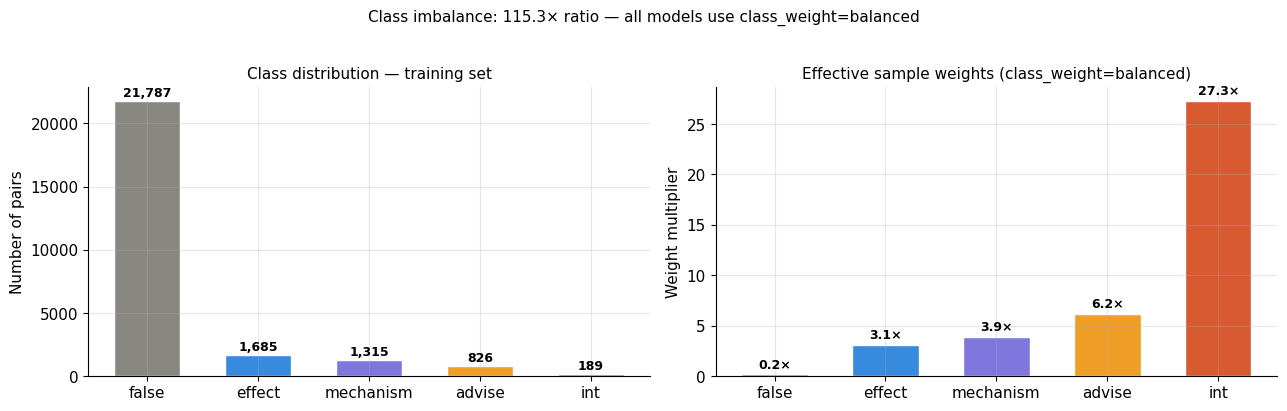

Imbalance ratio: 115.3×
Smallest class (int): only 189 training samples — hardest to learn


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = {cls: int((y_train == i).sum()) for i, cls in enumerate(CLASS_NAMES)}
counts_ordered  = [counts[l] for l in LABEL_ORDER]
colours         = [LABEL_COLOURS[l] for l in LABEL_ORDER]

# Left: raw counts
bars = axes[0].bar(LABEL_ORDER, counts_ordered, color=colours,
                   edgecolor='white', width=0.6)
for bar, val in zip(bars, counts_ordered):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Class distribution — training set', fontsize=11)
axes[0].set_ylabel('Number of pairs')

# Right: effective weights under balanced weighting
total   = len(y_train)
n_cls   = len(CLASS_NAMES)
weights = {cls: round(total / (n_cls * cnt), 1) for cls, cnt in counts.items()}
w_vals  = [weights[l] for l in LABEL_ORDER]
axes[1].bar(LABEL_ORDER, w_vals, color=colours, edgecolor='white', width=0.6)
for bar, val in zip(axes[1].patches, w_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val}×', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Effective sample weights (class_weight=balanced)', fontsize=11)
axes[1].set_ylabel('Weight multiplier')

ratio = max(counts_ordered) / min(counts_ordered)
plt.suptitle(f'Class imbalance: {ratio:.1f}× ratio — all models use class_weight=balanced',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_imbalance.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Imbalance ratio: {ratio:.1f}×')
print('Smallest class (int): only 189 training samples — hardest to learn')

## 5. Evaluation Functions

A single reusable `evaluate()` function is used across all models for consistent reporting.

**Metrics explained:**
- **Macro F1** — PRIMARY: equal weight per class, SemEval-2013 official protocol
- **MCC** — most robust single metric for severe class imbalance
- **Balanced Accuracy** — mean recall per class
- **Cohen Kappa** — agreement beyond chance
- **FNR** — False Negative Rate: proportion of real interactions missed (clinically critical)

**Why not AUC-ROC?** With 5,678 false-class test samples, TN is enormous and FPR stays artificially low. A model ignoring minority classes can still score ~0.85 AUC-ROC. PR-AUC (used in Section 11) does not use TN and cannot be inflated this way.

In [5]:
def compute_lower_level_metrics(y_true, y_pred, class_names):
    """
    Compute TP, FP, FN, TN and derived rates (Precision, Recall, FNR, Specificity)
    for each class from the confusion matrix.

    FNR (False Negative Rate) is the most clinically important metric here:
    a missed DDI = a patient not warned about a dangerous drug combination.
    """
    cm   = confusion_matrix(y_true, y_pred)
    rows = []
    for i, cls in enumerate(class_names):
        tp = int(cm[i, i])
        fp = int(cm[:, i].sum() - tp)
        fn = int(cm[i, :].sum() - tp)
        tn = int(cm.sum() - tp - fp - fn)

        precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # = Recall
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        fnr         = fn / (fn + tp) if (fn + tp) > 0 else 0.0   # missed rate
        f1          = (2 * precision * sensitivity / (precision + sensitivity)
                       if (precision + sensitivity) > 0 else 0.0)

        rows.append({'class': cls, 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
                     'Precision': round(precision, 4), 'Recall': round(sensitivity, 4),
                     'Specificity': round(specificity, 4), 'FNR': round(fnr, 4),
                     'F1': round(f1, 4)})
    return pd.DataFrame(rows)


def evaluate(model_name, y_true, y_pred, class_names, store=True):
    """
    Full evaluation: classification_report + high-level metrics + lower-level breakdown.
    Stores results in global dicts for later comparison if store=True.
    """
    report = classification_report(y_true, y_pred, target_names=class_names,
                                   output_dict=True, zero_division=0)

    print(f"\n{'='*68}")
    print(f'  {model_name}')
    print(f"{'='*68}")
    print(classification_report(y_true, y_pred, target_names=class_names,
                                zero_division=0, digits=4))

    macro_f1  = report['macro avg']['f1-score']
    accuracy  = report['accuracy']
    bal_acc   = balanced_accuracy_score(y_true, y_pred)
    mcc       = matthews_corrcoef(y_true, y_pred)
    kappa     = cohen_kappa_score(y_true, y_pred)
    wtd_f1    = report['weighted avg']['f1-score']

    print(f"  {'Metric':<28} {'Value':>10}  Notes")
    print(f"  {'-'*62}")
    print(f"  {'Accuracy':<28} {accuracy:>10.4f}  misleading for imbalanced data")
    print(f"  {'Balanced Accuracy':<28} {bal_acc:>10.4f}  mean recall per class")
    print(f"  {'Macro F1  [PRIMARY]':<28} {macro_f1:>10.4f}  SemEval-2013 official metric")
    print(f"  {'Weighted F1 (reference only)':<28} {wtd_f1:>10.4f}  dominated by false class")
    print(f"  {'MCC':<28} {mcc:>10.4f}  most robust for imbalance")
    print(f"  {'Cohen Kappa':<28} {kappa:>10.4f}  agreement beyond chance")

    # Lower-level breakdown
    ll = compute_lower_level_metrics(y_true, y_pred, class_names)
    ll_ord = ll.set_index('class').reindex(LABEL_ORDER).reset_index()
    print(f'\n  Lower-level breakdown:')
    print(f"  {'Class':<12} {'TP':>6} {'FP':>6} {'FN':>6} {'TN':>6} "          f"{'Precision':>10} {'Recall':>8} {'Specificity':>12} {'FNR':>6}")
    print(f"  {'-'*78}")
    for _, row in ll_ord.iterrows():
        flag = '  <- HIGH MISS RATE' if row['FNR'] > 0.5 and row['class'] != 'false' else ''
        print(f"  {row['class']:<12} {row['TP']:>6} {row['FP']:>6} {row['FN']:>6} {row['TN']:>6} "              f"{row['Precision']:>10.3f} {row['Recall']:>8.3f} "              f"{row['Specificity']:>12.3f} {row['FNR']:>6.3f}{flag}")
    print(f'\n  FNR = proportion of real interactions MISSED (clinically most critical)')

    # Confusion matrix printout
    cm  = confusion_matrix(y_true, y_pred)
    idx = [class_names.index(l) for l in LABEL_ORDER]
    cm_ord = cm[np.ix_(idx, idx)]
    print(f'\n  Confusion matrix (rows=true, cols=predicted):')
    print('  ' + ' ' * 14 + ''.join(f'{c:>11}' for c in LABEL_ORDER))
    for i, label in enumerate(LABEL_ORDER):
        print('  ' + f'{label:<14}' + ''.join(f'{v:>11,}' for v in cm_ord[i]))

    summary = {
        'accuracy': round(accuracy, 4), 'macro_f1': round(macro_f1, 4),
        'bal_acc':  round(bal_acc,  4), 'mcc':      round(mcc,      4),
        'kappa':    round(kappa,    4), 'wtd_f1':   round(wtd_f1,   4),
    }
    for label in LABEL_ORDER:
        summary[f'{label}_f1'] = round(report[label]['f1-score'], 4)

    if store:
        results[model_name]      = macro_f1
        summaries[model_name]    = summary
        all_preds[model_name]    = y_pred
        lower_level[model_name]  = ll

    return macro_f1, summary


def save_model(model, filename):
    path = os.path.join(MODELS_DIR, filename)
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    print(f'  Saved -> {path}')


# Global storage
results     = {}
summaries   = {}
all_preds   = {}
lower_level = {}
print('Evaluation functions defined.')

Evaluation functions defined.


## 6. Cross-Validation (Training Data Only)

5-fold stratified CV gives an unbiased estimate of generalisation performance before committing to full training. The SemEval test set is fixed and official — it is only used once for final evaluation.

**Stratified** = each fold preserves the class distribution, critical for 125× imbalanced data.

**Models included:**
- Naive Bayes, Logistic Regression, Random Forest, Linear SVM — all four ML models
- Rule-based is excluded — it has no learned parameters and produces identical predictions regardless of the training fold, so fold-by-fold scores would be meaningless

**Naive Bayes note:** Uses a `WeightedNB` wrapper that replicates the exact training cell behaviour (dense conversion, `words_between` sentinel clip, `sample_weight` for class balancing). This makes CV scores directly comparable to the final trained model.


In [6]:
# ── WeightedNB: custom wrapper so NB can run inside cross_val_score ─────────
# cross_val_score only calls fit(X, y) — it cannot pass sample_weight.
# WeightedNB handles dense conversion, sentinel clip, and class balancing
# internally inside fit(), making it fully compatible with cross_val_score.
# This mirrors the exact logic in the NB training cell below.
class WeightedNB(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha=0.1):
        self.alpha = alpha

    def _prepare_X(self, X):
        """Dense conversion + words_between sentinel clip — mirrors training cell."""
        X_d = X.toarray().astype(np.float32) if hasattr(X, 'toarray') else np.array(X, dtype=np.float32)
        wb_idx = X_d.shape[1] - 24 + 3   # words_between index (same as training cell)
        X_d[:, wb_idx] = np.clip(X_d[:, wb_idx], 0, None)
        return np.clip(X_d, 0, None)

    def fit(self, X, y):
        X_d = self._prepare_X(X)
        counts  = Counter(y)
        total   = len(y)
        n_cls   = len(np.unique(y))
        w_map   = {c: total / (n_cls * cnt) for c, cnt in counts.items()}
        sw      = np.array([w_map[yi] for yi in y])
        self._nb = MultinomialNB(alpha=self.alpha)
        self._nb.fit(X_d, y, sample_weight=sw)
        self.classes_ = self._nb.classes_
        return self

    def predict(self, X):
        return self._nb.predict(self._prepare_X(X))

    def predict_proba(self, X):
        return self._nb.predict_proba(self._prepare_X(X))


print(f'Running {CV_FOLDS}-fold stratified cross-validation on training data...')
print('Uses same hyperparameters as final training. Slower but gives honest CV estimates.')
print()

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    'Naive Bayes': WeightedNB(alpha=NB_ALPHA),
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', C=LR_C, max_iter=LR_MAX_ITER,
        solver='saga', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,   # 100 for CV speed; final model uses RF_N_ESTIMATORS
        class_weight='balanced', max_depth=RF_MAX_DEPTH,
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    'Linear SVM': LinearSVC(
        class_weight='balanced', C=SVM_C, max_iter=SVM_MAX_ITER,
        dual=False,   # primal form: faster when n_samples > n_features
        random_state=RANDOM_STATE
    ),
}

cv_results = {}
print(f"  {'Model':<22} {'Fold 1':>8} {'Fold 2':>8} {'Fold 3':>8} {'Fold 4':>8} {'Fold 5':>8} {'Mean':>8} {'Std':>7}")
print(f"  {'-'*88}")
for name, model in cv_models.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring='f1_macro', n_jobs=-1)
    cv_results[name] = scores
    fold_str = ''.join(f'{s:>8.4f}' for s in scores)
    print(f'  {name:<22}{fold_str} {scores.mean():>8.4f} {scores.std():>7.4f}')

print()
print('Interpretation:')
print('  Low std   = stable model, reliable across data subsets')
print('  High std  = sensitive to data split, less reliable')
print('  CV >> Test = model overfits training distribution — investigate feature mismatch')
print()
print('Note: Rule-based excluded — no learned parameters, CV scores would be identical across folds.')
print('Note: RF CV uses 100 trees (faster). Final RF uses RF_N_ESTIMATORS for best quality.')


Running 5-fold stratified cross-validation on training data...
Uses same hyperparameters as final training. Slower but gives honest CV estimates.

  Model                    Fold 1   Fold 2   Fold 3   Fold 4   Fold 5     Mean     Std
  ----------------------------------------------------------------------------------------
  Naive Bayes             0.3838  0.3890  0.3885  0.3844  0.3938   0.3879  0.0036
  Logistic Regression     0.4849  0.4666  0.4659  0.4894  0.4549   0.4724  0.0128
  Random Forest           0.5459  0.5473  0.5725  0.5414  0.5658   0.5546  0.0122
  Linear SVM              0.7293  0.7073  0.7188  0.7299  0.7203   0.7211  0.0083

Interpretation:
  Low std   = stable model, reliable across data subsets
  High std  = sensitive to data split, less reliable
  CV >> Test = model overfits training distribution — investigate feature mismatch

Note: Rule-based excluded — no learned parameters, CV scores would be identical across folds.
Note: RF CV uses 100 trees (faster). Final

## 7. Model 1 — Rule-Based Baseline

No machine learning. Scans each sentence for pharmacological keywords and assigns the interaction type based on which keywords are found. Priority: `mechanism > effect > advise > int > false`.

**Purpose:** This is the floor — every ML model must beat this to justify its complexity. It directly answers: *"Does ML beat keyword matching?"*

In [7]:
RULES = {
    'mechanism': {'inhibit', 'induce', 'metabolis', 'metaboliz', 'cyp', 'enzyme',
                  'absorption', 'clearance', 'half-life', 'bioavailability', 'pharmacokinetic'},
    'effect':    {'bleeding', 'toxicity', 'sedation', 'hypotension', 'bradycardia',
                  'adverse', 'side effect', 'prolonged', 'elevated'},
    'advise':    {'contraindicated', 'avoid', 'caution', 'recommend', 'monitor',
                  'warning', 'should not', 'do not', 'concomitant'},
    'int':       {'interact', 'interaction', 'combined with', 'co-administration', 'combination'},
}

def rule_based_predict(sentences):
    """Keyword-priority classifier. No learning — pure pattern matching."""
    preds = []
    for sent in sentences:
        sl   = str(sent).lower()
        pred = 'false'
        for label in ['mechanism', 'effect', 'advise', 'int']:
            if any(kw in sl for kw in RULES[label]):
                pred = label
                break
        preds.append(pred)
    return preds

test_df            = pd.read_csv(TEST_CSV)
rule_preds_str     = rule_based_predict(test_df['sentence_cleaned'])
rule_preds_encoded = encoder.transform(rule_preds_str)

evaluate('Rule-based', y_test, rule_preds_encoded, CLASS_NAMES)
rb_f1 = results['Rule-based']


  Rule-based
              precision    recall  f1-score   support

      advise     0.1065    0.5385    0.1779       221
      effect     0.1739    0.1667    0.1702       360
       false     0.8544    0.2955    0.4392      5678
         int     0.0401    0.2083    0.0672        96
   mechanism     0.0794    0.7185    0.1430       302

    accuracy                         0.3146      6657
   macro avg     0.2509    0.3855    0.1995      6657
weighted avg     0.7459    0.3146    0.3971      6657

  Metric                            Value  Notes
  --------------------------------------------------------------
  Accuracy                         0.3146  misleading for imbalanced data
  Balanced Accuracy                0.3855  mean recall per class
  Macro F1  [PRIMARY]              0.1995  SemEval-2013 official metric
  Weighted F1 (reference only)     0.3971  dominated by false class
  MCC                              0.0803  most robust for imbalance
  Cohen Kappa                      

## 8. Model 2 — Naive Bayes

Probabilistic classifier. Fast and interpretable, but assumes feature independence (rarely true for text). Uses `sample_weight` to handle imbalance since `MultinomialNB` has no `class_weight` parameter.

**Bug fixed:** `NB_ALPHA` is now correctly read from the config cell instead of being hardcoded.

**NB clipping note:** The `words_between` feature uses `-1` as a sentinel (drug not found in sentence). For Naive Bayes (which requires non-negative inputs), we replace `-1` specifically with `0` to preserve the meaning of other features — rather than clipping the entire matrix which would conflate "not found" with "adjacent".

In [8]:
print('Training Naive Bayes...')
print(f'  alpha={NB_ALPHA} (from config — Laplace smoothing)')

# MultinomialNB requires non-negative features
# Fix: replace only the words_between sentinel (-1) with 0
# Do NOT clip the entire matrix — this would conflate sentinel with adjacent drugs
X_train_nb = X_train.copy().toarray().astype(np.float32)
X_test_nb  = X_test.copy().toarray().astype(np.float32)

# words_between is the 4th handcrafted feature (index -21 from end, or index 5003)
words_between_idx = X_train.shape[1] - 24 + 3   # position in feature block
X_train_nb[:, words_between_idx] = np.clip(X_train_nb[:, words_between_idx], 0, None)
X_test_nb[:, words_between_idx]  = np.clip(X_test_nb[:, words_between_idx],  0, None)

# Any remaining negatives (safety net) — should be none after above fix
X_train_nb = np.clip(X_train_nb, 0, None)
X_test_nb  = np.clip(X_test_nb,  0, None)

# Compute sample weights (class_weight=balanced equivalent)
class_counts  = Counter(y_train)
total_samples = len(y_train)
n_classes     = len(CLASS_NAMES)
weight_map    = {cls: total_samples / (n_classes * cnt) for cls, cnt in class_counts.items()}
sample_wts    = np.array([weight_map[y] for y in y_train])

nb_model = MultinomialNB(alpha=NB_ALPHA)   # ← correctly uses config value
nb_model.fit(X_train_nb, y_train, sample_weight=sample_wts)
nb_preds = nb_model.predict(X_test_nb)

evaluate('Naive Bayes', y_test, nb_preds, CLASS_NAMES)
save_model(nb_model, 'naive_bayes.pkl')

Training Naive Bayes...
  alpha=0.1 (from config — Laplace smoothing)

  Naive Bayes
              precision    recall  f1-score   support

      advise     0.2365    0.6742    0.3502       221
      effect     0.1597    0.7889    0.2657       360
       false     0.9623    0.5077    0.6647      5678
         int     0.2368    0.0938    0.1343        96
   mechanism     0.1967    0.7914    0.3151       302

    accuracy                         0.5354      6657
   macro avg     0.3584    0.5712    0.3460      6657
weighted avg     0.8496    0.5354    0.6092      6657

  Metric                            Value  Notes
  --------------------------------------------------------------
  Accuracy                         0.5354  misleading for imbalanced data
  Balanced Accuracy                0.5712  mean recall per class
  Macro F1  [PRIMARY]              0.3460  SemEval-2013 official metric
  Weighted F1 (reference only)     0.6092  dominated by false class
  MCC                            

## 9. Model 3 — Logistic Regression

Strong linear classifier with calibrated probabilities. Uses `solver='saga'` — the fastest solver for large sparse matrices. Provides `predict_proba` which enables Precision-Recall curve analysis in Section 11.

In [9]:
print('Training Logistic Regression...')
print(f'  solver=saga, C={LR_C}, max_iter={LR_MAX_ITER}')
print('  (this takes ~1-2 minutes)')

lr = LogisticRegression(
    class_weight = 'balanced',
    C            = LR_C,
    max_iter     = LR_MAX_ITER,
    solver       = 'saga',          # fastest for large sparse data
    random_state = RANDOM_STATE,
    # Note: multi_class parameter removed — deprecated in sklearn >= 1.0
    # Multinomial softmax is used automatically for 5-class problems
)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

evaluate('Logistic Regression', y_test, lr_preds, CLASS_NAMES)
save_model(lr, 'logistic_regression.pkl')

Training Logistic Regression...
  solver=saga, C=1.0, max_iter=1000
  (this takes ~1-2 minutes)

  Logistic Regression
              precision    recall  f1-score   support

      advise     0.2368    0.7738    0.3627       221
      effect     0.2212    0.7000    0.3362       360
       false     0.9592    0.6464    0.7723      5678
         int     0.1488    0.3750    0.2130        96
   mechanism     0.2802    0.6755    0.3961       302

    accuracy                         0.6509      6657
   macro avg     0.3693    0.6341    0.4161      6657
weighted avg     0.8528    0.6509    0.7100      6657

  Metric                            Value  Notes
  --------------------------------------------------------------
  Accuracy                         0.6509  misleading for imbalanced data
  Balanced Accuracy                0.6341  mean recall per class
  Macro F1  [PRIMARY]              0.4161  SemEval-2013 official metric
  Weighted F1 (reference only)     0.7100  dominated by false class

## 10. Model 4 — Random Forest

Ensemble of decision trees. Handles the mixed feature space (sparse TF-IDF + dense handcrafted) better than linear models. Provides feature importance scores for free.

In [10]:
print('Training Random Forest...')
print(f'  {RF_N_ESTIMATORS} trees, max_depth={RF_MAX_DEPTH}, class_weight=balanced')
print('  (this takes ~3-4 minutes)')

rf = RandomForestClassifier(
    n_estimators = RF_N_ESTIMATORS,
    class_weight = 'balanced',
    max_depth    = RF_MAX_DEPTH,
    n_jobs       = -1,
    random_state = RANDOM_STATE,
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

evaluate('Random Forest', y_test, rf_preds, CLASS_NAMES)
save_model(rf, 'random_forest.pkl')

Training Random Forest...
  200 trees, max_depth=20, class_weight=balanced
  (this takes ~3-4 minutes)

  Random Forest
              precision    recall  f1-score   support

      advise     0.2126    0.8100    0.3368       221
      effect     0.1869    0.7056    0.2955       360
       false     0.9629    0.5525    0.7021      5678
         int     0.3093    0.3125    0.3109        96
   mechanism     0.2216    0.8079    0.3478       302

    accuracy                         0.5774      6657
   macro avg     0.3786    0.6377    0.3986      6657
weighted avg     0.8529    0.5774    0.6463      6657

  Metric                            Value  Notes
  --------------------------------------------------------------
  Accuracy                         0.5774  misleading for imbalanced data
  Balanced Accuracy                0.6377  mean recall per class
  Macro F1  [PRIMARY]              0.3986  SemEval-2013 official metric
  Weighted F1 (reference only)     0.6463  dominated by false clas

## 11. Model 5 — Linear SVM

Maximum-margin classifier — the gold standard for high-dimensional sparse text classification. Finds the hyperplane that best separates classes in the 5,024-dimensional feature space.

**Why SVM excels on text:** TF-IDF produces very high-dimensional sparse vectors. SVM ignores the 98.9% zero entries and focuses only on the discriminative non-zero features.

**Bug fixed:** `dual=False` is now uncommented. With n_samples (27,792) > n_features (5,024), the primal formulation is both faster and mathematically preferred.

In [11]:
print('Training Linear SVM...')
print(f'  C={SVM_C}, dual=False (primal form, faster when n_samples > n_features)')
print(f'  class_weight=balanced, max_iter={SVM_MAX_ITER}')

svm = LinearSVC(
    class_weight = 'balanced',
    C            = SVM_C,
    max_iter     = SVM_MAX_ITER,
    dual         = False,      # primal: faster when n_samples > n_features (our case)
    random_state = RANDOM_STATE,
)
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)

evaluate('Linear SVM', y_test, svm_preds, CLASS_NAMES)
save_model(svm, 'svm.pkl')

# Calibrated SVM for probability-based evaluation (PR curves)
print('\nFitting calibrated SVM for probability estimates (PR curves)...')
svm_base = LinearSVC(class_weight='balanced', C=SVM_C,
                     dual=False, max_iter=SVM_MAX_ITER, random_state=RANDOM_STATE)
svm_cal  = CalibratedClassifierCV(svm_base, cv=3)
svm_cal.fit(X_train, y_train)
print('  Calibrated SVM ready.')

Training Linear SVM...
  C=0.5, dual=False (primal form, faster when n_samples > n_features)
  class_weight=balanced, max_iter=3000

  Linear SVM
              precision    recall  f1-score   support

      advise     0.4114    0.6516    0.5044       221
      effect     0.2942    0.6472    0.4045       360
       false     0.9480    0.8353    0.8881      5678
         int     0.4253    0.3854    0.4044        96
   mechanism     0.4518    0.6358    0.5282       302

    accuracy                         0.8035      6657
   macro avg     0.5061    0.6311    0.5459      6657
weighted avg     0.8648    0.8035    0.8259      6657

  Metric                            Value  Notes
  --------------------------------------------------------------
  Accuracy                         0.8035  misleading for imbalanced data
  Balanced Accuracy                0.6311  mean recall per class
  Macro F1  [PRIMARY]              0.5459  SemEval-2013 official metric
  Weighted F1 (reference only)     0.825

## 12. Model Comparison & Benchmark Check

In [12]:
best_model = max(results, key=results.get)
rb_f1      = results.get('Rule-based', 0)

print(f"\n{'='*90}")
print('  FINAL MODEL COMPARISON')
print(f"{'='*90}")
print(f"  {'Model':<22} {'Accuracy':>9} {'Bal.Acc':>8} {'Macro F1':>9} {'MCC':>8} {'Kappa':>8} {'Wtd F1':>8}")
print(f"  {'-'*78}")
for name, s in summaries.items():
    star = '  <- BEST' if name == best_model else ''
    print(f"  {name:<22} {s['accuracy']:>9.4f} {s['bal_acc']:>8.4f} {s['macro_f1']:>9.4f} "          f"{s['mcc']:>8.4f} {s['kappa']:>8.4f} {s['wtd_f1']:>8.4f}{star}")

print(f'\n  PRIMARY METRIC: Macro F1 — best model: {best_model} ({results[best_model]:.4f})')
print(f'  ML improvement over rule-based baseline: +{results[best_model] - rb_f1:.4f}')

print(f'\n  Per-class F1:')
print(f"  {'Model':<22} {'false':>8} {'effect':>9} {'mechanism':>11} {'advise':>8} {'int':>6}")
print(f"  {'-'*68}")
for name, s in summaries.items():
    print(f"  {name:<22} {s['false_f1']:>8.3f} {s['effect_f1']:>9.3f} "          f"{s['mechanism_f1']:>11.3f} {s['advise_f1']:>8.3f} {s['int_f1']:>6.3f}")

# Benchmark check
best_f1 = results[best_model]
print(f"\n{'='*60}")
print('  BENCHMARK CHECK')
print(f"{'='*60}")
if best_f1 >= BENCHMARK_MAX:
    verdict = 'EXCELLENT — above competitive range. Proceed to Phase 5 (BioBERT).'
elif best_f1 >= BENCHMARK_TARGET:
    verdict = 'GOOD — within competitive range. Phase 5 (BioBERT) will push to 0.72+.'
elif best_f1 >= BENCHMARK_MIN:
    verdict = 'ADEQUATE — at lower bound. Consider optimising SVM_C before Phase 5.'
else:
    verdict = 'BELOW TARGET — increase SVM_C to 2.0 and re-run before Phase 5.'
print(f'  Best Macro F1 : {best_f1:.4f}')
print(f'  Target        : >= {BENCHMARK_TARGET}')
print(f'  Verdict       : {verdict}')


  FINAL MODEL COMPARISON
  Model                   Accuracy  Bal.Acc  Macro F1      MCC    Kappa   Wtd F1
  ------------------------------------------------------------------------------
  Rule-based                0.3146   0.3855    0.1995   0.0803   0.0484   0.3971
  Naive Bayes               0.5354   0.5712    0.3460   0.2943   0.2128   0.6092
  Logistic Regression       0.6509   0.6341    0.4161   0.3517   0.2896   0.7100
  Random Forest             0.5774   0.6377    0.3986   0.3233   0.2449   0.6463
  Linear SVM                0.8035   0.6311    0.5459   0.4555   0.4349   0.8259  <- BEST

  PRIMARY METRIC: Macro F1 — best model: Linear SVM (0.5459)
  ML improvement over rule-based baseline: +0.3464

  Per-class F1:
  Model                     false    effect   mechanism   advise    int
  --------------------------------------------------------------------
  Rule-based                0.439     0.170       0.143    0.178  0.067
  Naive Bayes               0.665     0.266       0.3

## 13. Visualisation 1 — Overall Model Comparison

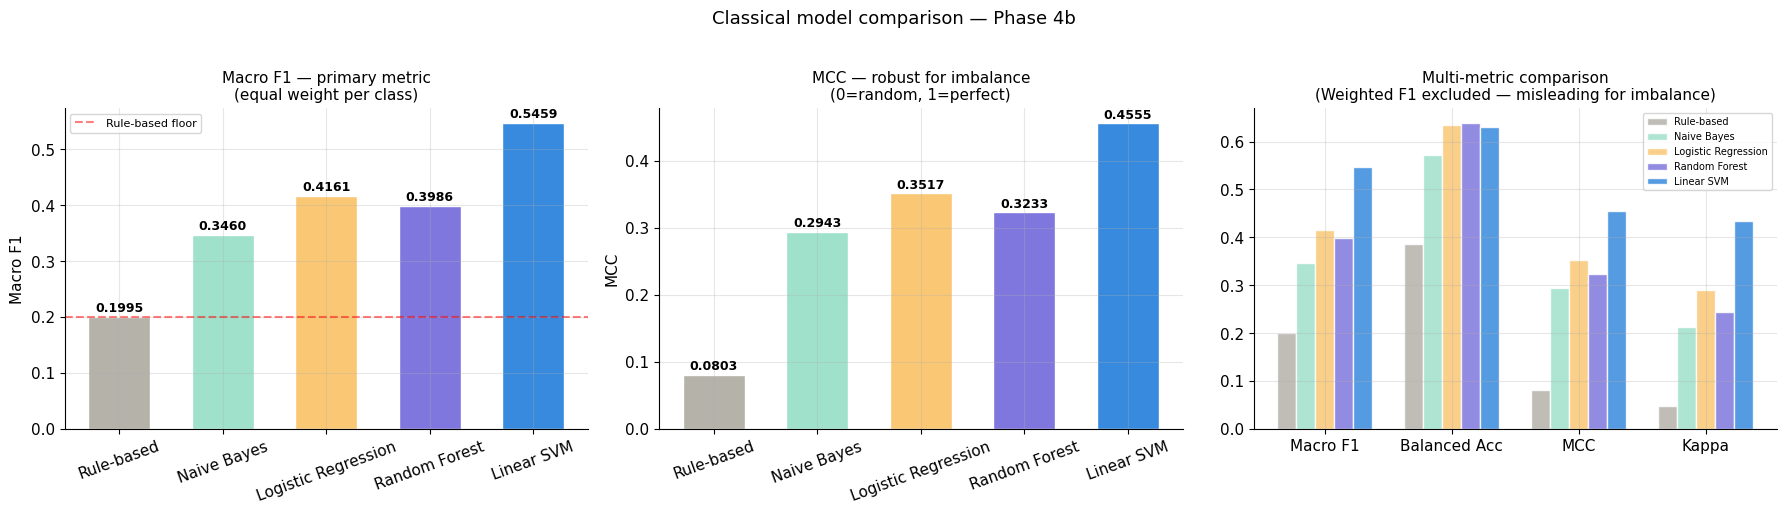

In [13]:
model_list  = list(results.keys())
colours_bar = [MODEL_COLOURS.get(m, '#888780') for m in model_list]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Macro F1
f1_vals = [results[m] for m in model_list]
bars = axes[0].bar(model_list, f1_vals, color=colours_bar, edgecolor='white', width=0.6)
for bar, val in zip(bars, f1_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].axhline(y=rb_f1, color='red', linestyle='--', alpha=0.5, label='Rule-based floor')
axes[0].set_title('Macro F1 — primary metric\n(equal weight per class)', fontsize=11)
axes[0].set_ylabel('Macro F1')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(fontsize=8)

# Middle: MCC
mcc_vals = [summaries[m]['mcc'] for m in model_list]
bars2    = axes[1].bar(model_list, mcc_vals, color=colours_bar, edgecolor='white', width=0.6)
for bar, val in zip(bars2, mcc_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('MCC — robust for imbalance\n(0=random, 1=perfect)', fontsize=11)
axes[1].set_ylabel('MCC')
axes[1].tick_params(axis='x', rotation=20)

# Right: multi-metric grouped bar
metric_keys   = ['macro_f1', 'bal_acc', 'mcc', 'kappa']
metric_labels = ['Macro F1', 'Balanced Acc', 'MCC', 'Kappa']
x = np.arange(len(metric_labels))
w = 0.15
for j, (name, col) in enumerate(zip(model_list, colours_bar)):
    vals = [summaries[name][k] for k in metric_keys]
    axes[2].bar(x + j*w - w*2, vals, w, label=name, color=col, alpha=0.85, edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(metric_labels)
axes[2].set_title('Multi-metric comparison\n(Weighted F1 excluded — misleading for imbalance)', fontsize=11)
axes[2].legend(fontsize=7, loc='upper right')

plt.suptitle('Classical model comparison — Phase 4b', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'viz1_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 14. Visualisation 2 — Per-Class F1 Heatmap

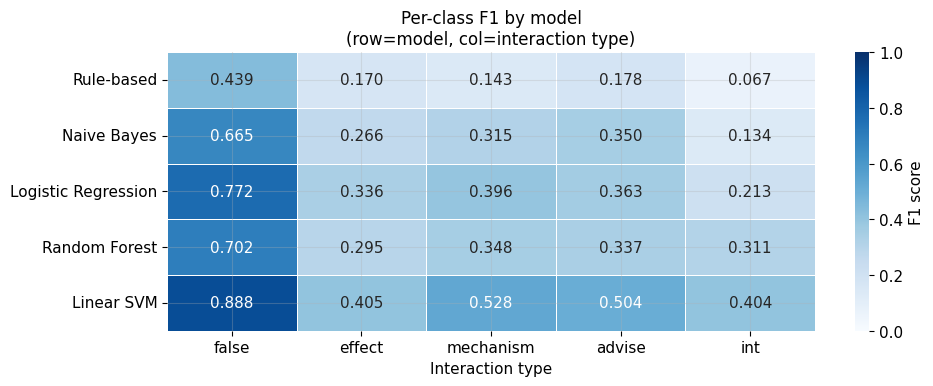

int column is typically lightest — 96 test samples, hardest class to learn
advise column often strongest — distinctive vocabulary (contraindicated, avoid, monitor)


In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
hm_data = pd.DataFrame(
    [[summaries[m][f'{l}_f1'] for l in LABEL_ORDER] for m in model_list],
    index=model_list, columns=LABEL_ORDER
)
sns.heatmap(hm_data, ax=ax, annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, vmin=0, vmax=1, cbar_kws={'label': 'F1 score'})
ax.set_title('Per-class F1 by model\n(row=model, col=interaction type)', fontsize=12)
ax.set_xlabel('Interaction type')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'viz2_perclass_f1_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('int column is typically lightest — 96 test samples, hardest class to learn')
print('advise column often strongest — distinctive vocabulary (contraindicated, avoid, monitor)')

## 15. Visualisation 3 — False Negative Rate (Clinical View)

FNR = proportion of real interactions the model MISSED. In a DDI detection system, a missed interaction = a patient not warned about a dangerous drug combination. **FNR on interaction classes is the most clinically important metric in this project.**

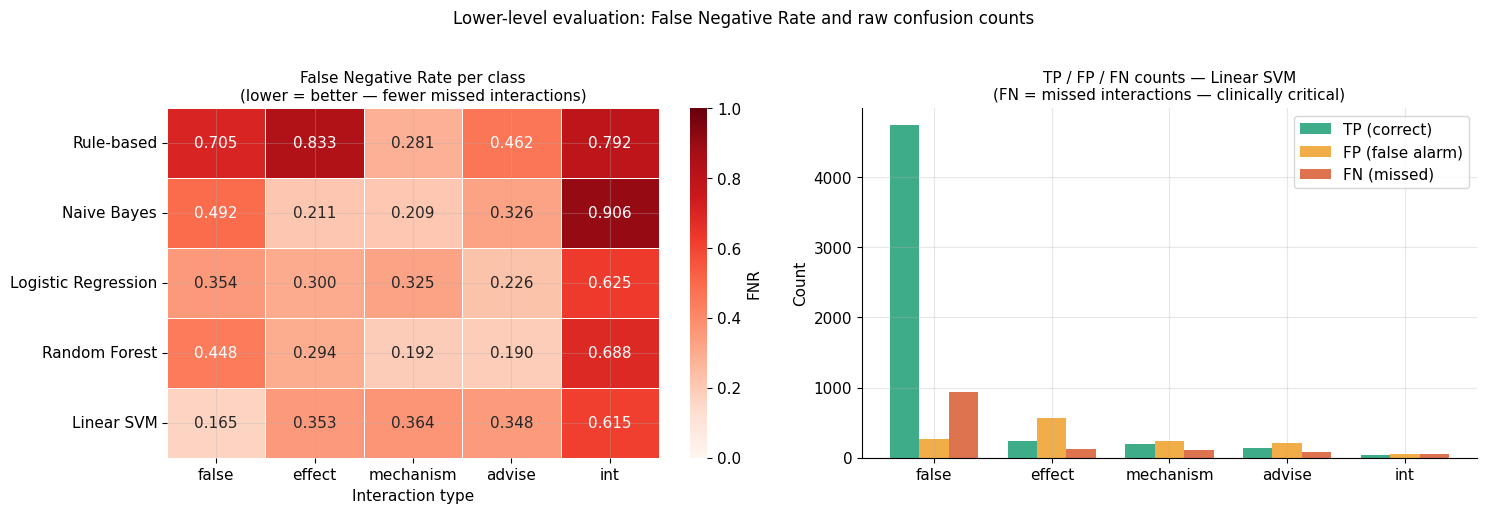

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: FNR heatmap per class per model
fnr_data = {}
for name in model_list:
    ll = lower_level[name].set_index('class').reindex(LABEL_ORDER)
    fnr_data[name] = ll['FNR'].values

fnr_df = pd.DataFrame(fnr_data, index=LABEL_ORDER)
sns.heatmap(fnr_df.T, ax=axes[0], annot=True, fmt='.3f', cmap='Reds',
            linewidths=0.5, vmin=0, vmax=1, cbar_kws={'label': 'FNR'})
axes[0].set_title('False Negative Rate per class\n(lower = better — fewer missed interactions)', fontsize=11)
axes[0].set_xlabel('Interaction type')

# Right: TP / FP / FN for best model
ll_best = lower_level[best_model].set_index('class').reindex(LABEL_ORDER).reset_index()
x = np.arange(len(LABEL_ORDER))
w = 0.25
axes[1].bar(x - w,   ll_best['TP'], w, label='TP (correct)',     color='#1D9E75', alpha=0.85)
axes[1].bar(x,       ll_best['FP'], w, label='FP (false alarm)',  color='#EF9F27', alpha=0.85)
axes[1].bar(x + w,   ll_best['FN'], w, label='FN (missed)',       color='#D85A30', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(LABEL_ORDER)
axes[1].set_title(f'TP / FP / FN counts — {best_model}\n(FN = missed interactions — clinically critical)', fontsize=11)
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Lower-level evaluation: False Negative Rate and raw confusion counts', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'viz3_fnr_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## 16. Visualisation 4 — Normalised Confusion Matrices

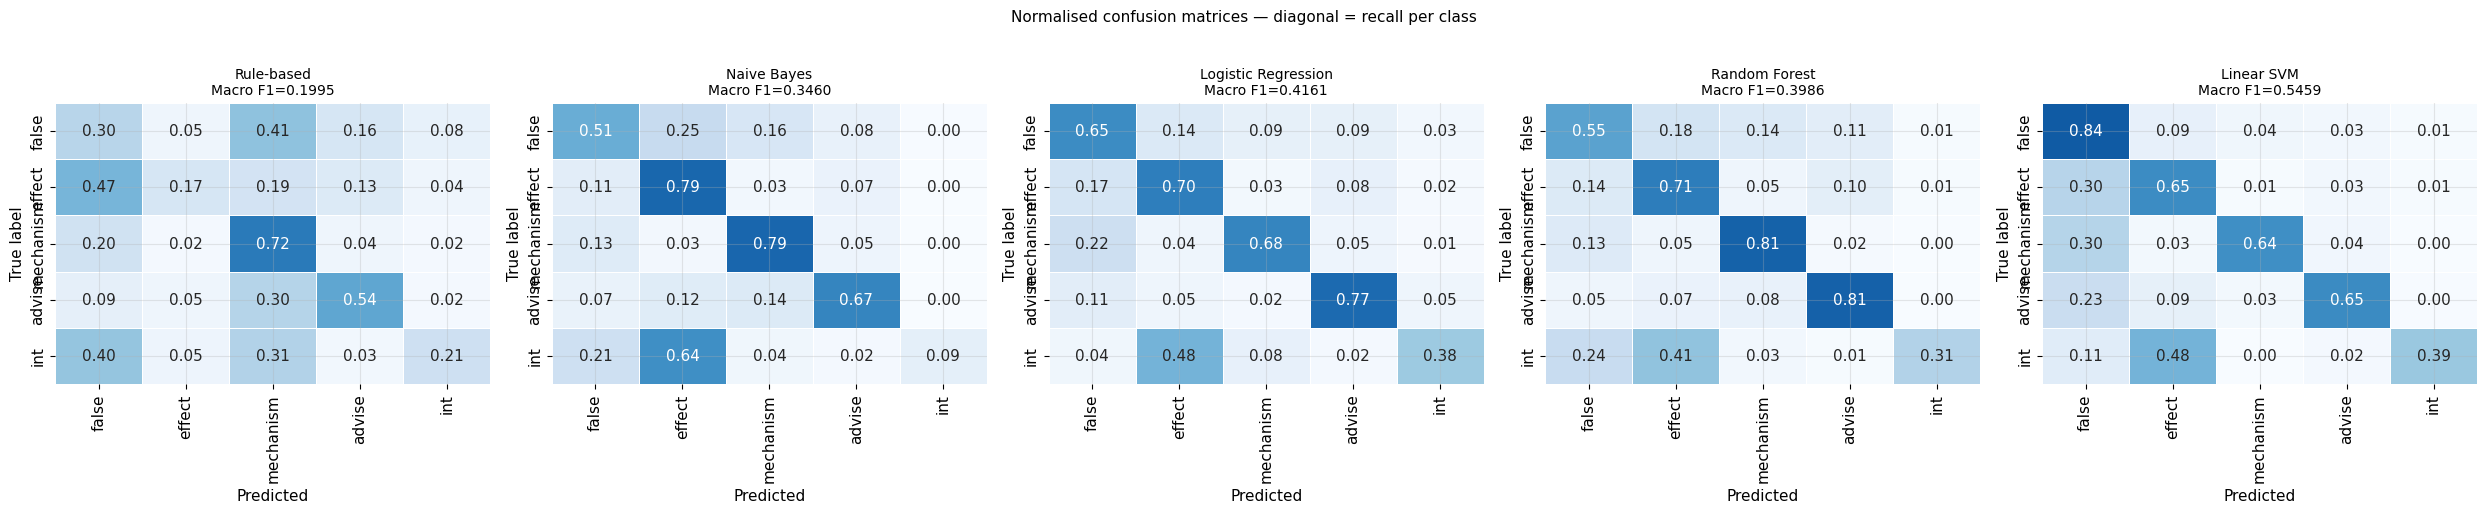

Diagonal = recall (how often the true class is correctly predicted)
Off-diagonal = confusion patterns (e.g., mechanism predicted as effect)


In [16]:
fig, axes = plt.subplots(1, len(model_list), figsize=(5 * len(model_list), 5))
if len(model_list) == 1:
    axes = [axes]

idx = [CLASS_NAMES.index(l) for l in LABEL_ORDER]

for ax, (name, preds) in zip(axes, all_preds.items()):
    cm     = confusion_matrix(y_test, preds)
    cm_ord = cm[np.ix_(idx, idx)]

    # Normalise by true class (row) — shows recall per class
    row_sums = cm_ord.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    cm_norm = cm_ord / row_sums

    sns.heatmap(cm_norm, ax=ax, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
                vmin=0, vmax=1, cbar=False, linewidths=0.5)
    ax.set_title(f'{name}\nMacro F1={results[name]:.4f}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True label')

plt.suptitle('Normalised confusion matrices — diagonal = recall per class',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'viz4_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Diagonal = recall (how often the true class is correctly predicted)')
print('Off-diagonal = confusion patterns (e.g., mechanism predicted as effect)')

## 17. Visualisation 5 — Precision-Recall Curves & CV Stability

**PR-AUC is used instead of AUC-ROC.** With 5,678 `false`-class test samples, TN is enormous and FPR stays artificially low — a model ignoring minority classes scores ~0.85 AUC-ROC. PR curves do not use TN and cannot be inflated this way.

PR curves are shown for both Logistic Regression (native probabilities) and calibrated SVM (isotonic regression calibration).

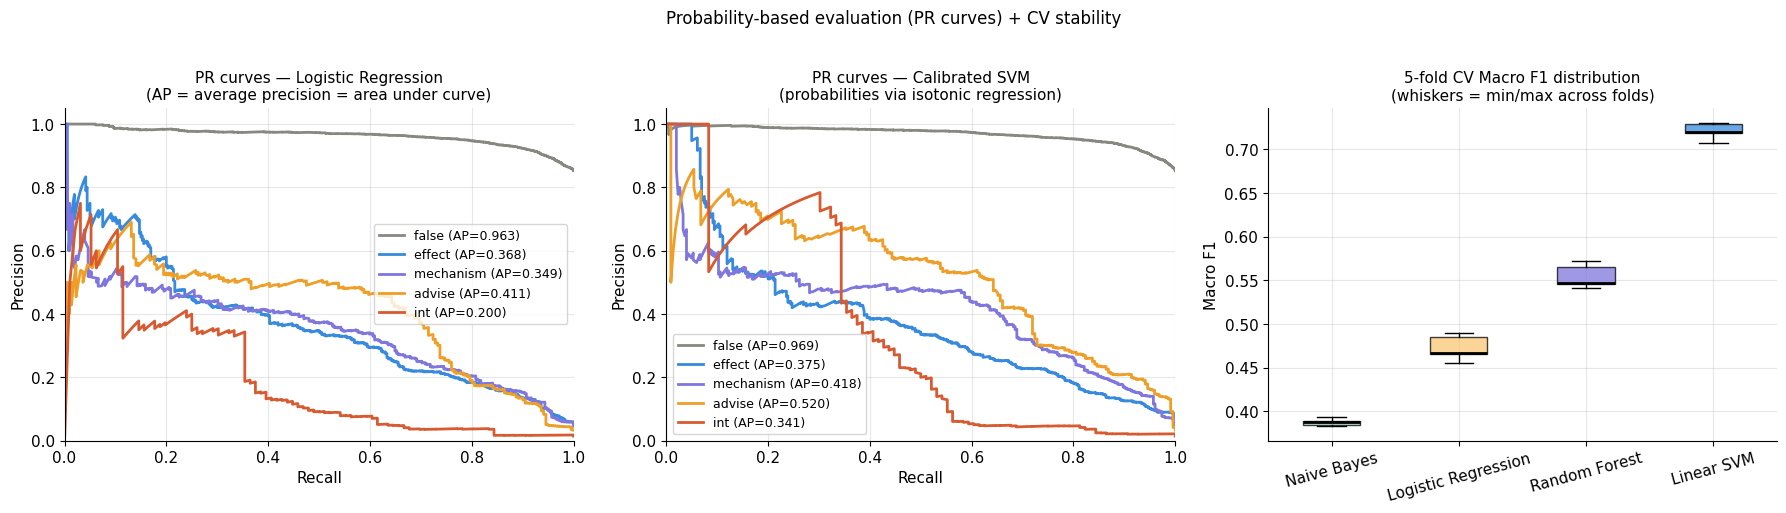

In [17]:
y_test_bin = label_binarize(y_test, classes=list(range(len(CLASS_NAMES))))
lr_probs   = lr.predict_proba(X_test)
svm_probs  = svm_cal.predict_proba(X_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: LR Precision-Recall curves
for i, label in enumerate(LABEL_ORDER):
    cls_idx  = CLASS_NAMES.index(label)
    prec, rec, _ = precision_recall_curve(y_test_bin[:, cls_idx], lr_probs[:, cls_idx])
    ap = average_precision_score(y_test_bin[:, cls_idx], lr_probs[:, cls_idx])
    axes[0].plot(rec, prec, label=f'{label} (AP={ap:.3f})',
                 color=LABEL_COLOURS[label], linewidth=2)
axes[0].set_title('PR curves — Logistic Regression\n(AP = average precision = area under curve)', fontsize=11)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].legend(fontsize=9)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])

# Middle: Calibrated SVM Precision-Recall curves
for i, label in enumerate(LABEL_ORDER):
    cls_idx  = CLASS_NAMES.index(label)
    prec, rec, _ = precision_recall_curve(y_test_bin[:, cls_idx], svm_probs[:, cls_idx])
    ap = average_precision_score(y_test_bin[:, cls_idx], svm_probs[:, cls_idx])
    axes[1].plot(rec, prec, label=f'{label} (AP={ap:.3f})',
                 color=LABEL_COLOURS[label], linewidth=2)
axes[1].set_title('PR curves — Calibrated SVM\n(probabilities via isotonic regression)', fontsize=11)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

# Right: CV stability boxplot
cv_model_names = list(cv_results.keys())
bp = axes[2].boxplot([cv_results[m] for m in cv_model_names],
                     labels=cv_model_names, patch_artist=True,
                     medianprops={'color': 'black', 'linewidth': 2})
for patch, col in zip(bp['boxes'], [MODEL_COLOURS.get(m, '#888780') for m in cv_model_names]):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
axes[2].set_title(f'{CV_FOLDS}-fold CV Macro F1 distribution\n(whiskers = min/max across folds)', fontsize=11)
axes[2].set_ylabel('Macro F1')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Probability-based evaluation (PR curves) + CV stability', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'viz5_pr_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 18. Visualisation 6 — Feature Importance (Random Forest)

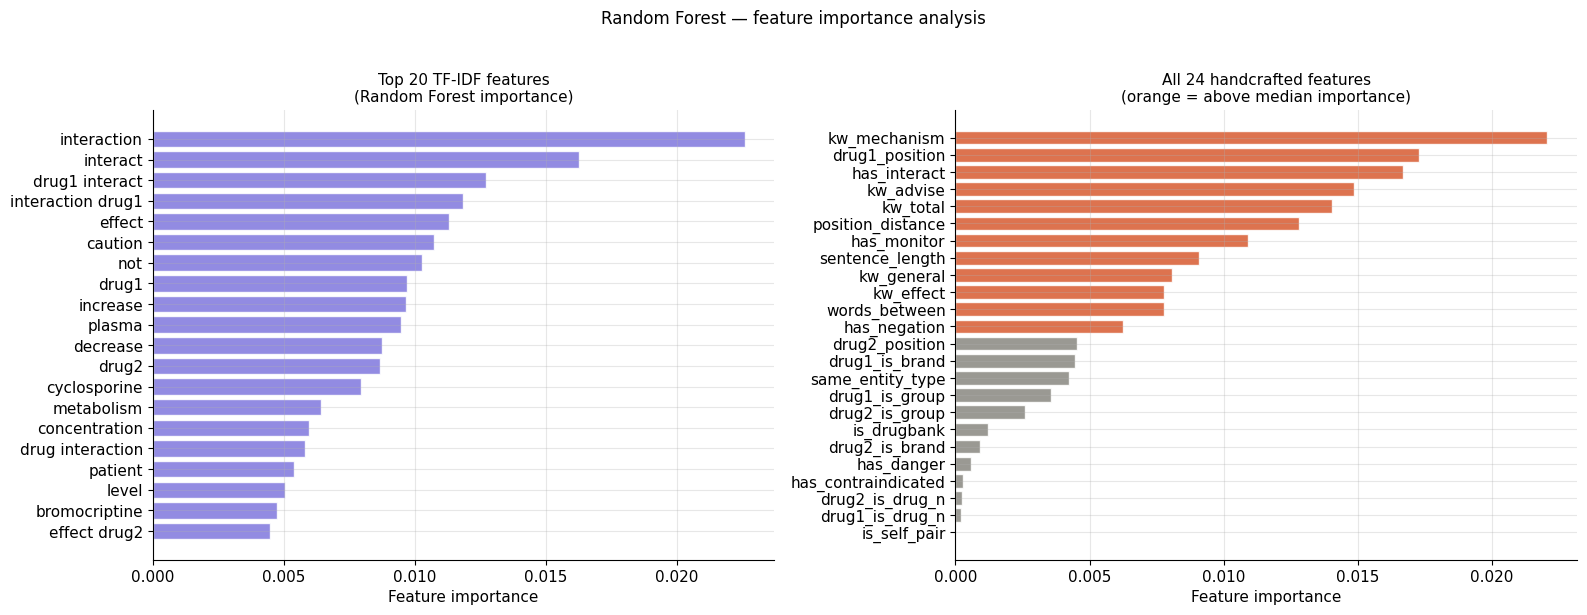

Top 10 handcrafted features by importance:
  kw_mechanism                 0.022057
  drug1_position               0.017288
  has_interact                 0.016688
  kw_advise                    0.014844
  kw_total                     0.014025
  position_distance            0.012795
  has_monitor                  0.010911
  sentence_length              0.009090
  kw_general                   0.008074
  kw_effect                    0.007766


In [18]:
importances  = rf.feature_importances_
tfidf_imp    = importances[:5000]
hc_imp       = importances[5000:]      # last 24 = handcrafted block
hc_names     = feature_names[5000:]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: top 20 TF-IDF features
top20_idx = np.argsort(tfidf_imp)[-20:]
axes[0].barh([feature_names[i] for i in top20_idx], tfidf_imp[top20_idx],
             color='#7F77DD', alpha=0.85, edgecolor='white')
axes[0].set_title('Top 20 TF-IDF features\n(Random Forest importance)', fontsize=11)
axes[0].set_xlabel('Feature importance')

# Right: all 24 handcrafted features
hc_order = np.argsort(hc_imp)
hc_cols  = ['#D85A30' if v > np.median(hc_imp) else '#888780' for v in hc_imp[hc_order]]
axes[1].barh([hc_names[i] for i in hc_order], [hc_imp[i] for i in hc_order],
             color=hc_cols, alpha=0.85, edgecolor='white')
axes[1].set_title('All 24 handcrafted features\n(orange = above median importance)', fontsize=11)
axes[1].set_xlabel('Feature importance')

plt.suptitle('Random Forest — feature importance analysis', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'viz6_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 handcrafted features by importance:')
for i in reversed(hc_order[-10:]):
    print(f'  {hc_names[i]:<28} {hc_imp[i]:.6f}')

## 19. Visualisation 7 — CV vs Test Performance Gap

A large CV vs Test gap = overfitting or feature distribution mismatch between training and test. This is the most important diagnostic for understanding why performance may be lower than expected.

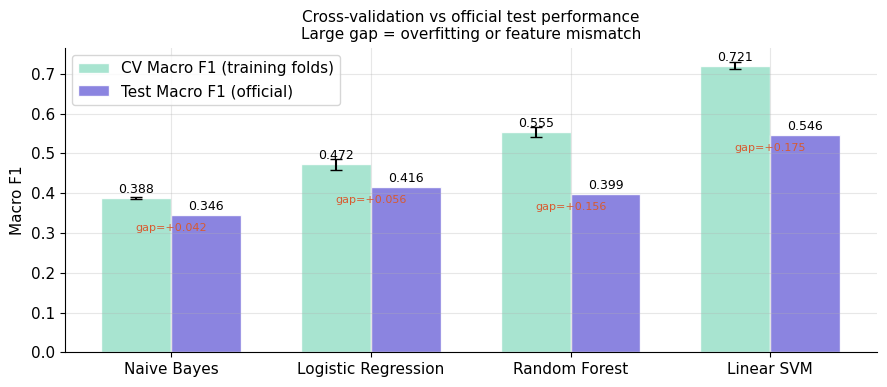

Gap interpretation:
  Naive Bayes            CV=0.3879  Test=0.3460  Gap=+0.0419  [SMALL — reliable]
  Logistic Regression    CV=0.4724  Test=0.4161  Gap=+0.0563  [MODERATE — normal for text classification]
  Random Forest          CV=0.5546  Test=0.3986  Gap=+0.1560  [LARGE — investigate feature mismatch]
  Linear SVM             CV=0.7211  Test=0.5459  Gap=+0.1752  [LARGE — investigate feature mismatch]


In [19]:
common    = [m for m in cv_results if m in results]
cv_means  = [cv_results[m].mean() for m in common]
cv_stds   = [cv_results[m].std()  for m in common]
test_f1s  = [results[m]           for m in common]

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(common))
w = 0.35

ax.bar(x - w/2, cv_means, w, label='CV Macro F1 (training folds)',
       color='#9FE1CB', edgecolor='white', alpha=0.9, yerr=cv_stds, capsize=4)
ax.bar(x + w/2, test_f1s, w, label='Test Macro F1 (official)',
       color='#7F77DD', edgecolor='white', alpha=0.9)

for i, (cv_v, te_v) in enumerate(zip(cv_means, test_f1s)):
    ax.text(i - w/2, cv_v + 0.005, f'{cv_v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + w/2, te_v + 0.005, f'{te_v:.3f}', ha='center', va='bottom', fontsize=9)
    gap = cv_v - te_v
    ax.text(i, min(cv_v, te_v) - 0.02,
            f'gap={gap:+.3f}', ha='center', va='top', fontsize=8, color='#D85A30')

ax.set_xticks(x)
ax.set_xticklabels(common)
ax.set_ylabel('Macro F1')
ax.set_title('Cross-validation vs official test performance\n'             'Large gap = overfitting or feature mismatch', fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'viz7_cv_vs_test.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Gap interpretation:')
for name, cv_v, te_v in zip(common, cv_means, test_f1s):
    gap   = cv_v - te_v
    level = 'LARGE — investigate feature mismatch' if gap > 0.10 else             'MODERATE — normal for text classification' if gap > 0.05 else 'SMALL — reliable'
    print(f'  {name:<22} CV={cv_v:.4f}  Test={te_v:.4f}  Gap={gap:+.4f}  [{level}]')

## 20. Error Analysis — Dangerous Misses

Classifying a real interaction as `false` means a patient is not warned. These are the most clinically dangerous errors and the most important to analyse and minimise.

In [20]:
# Guard: load test_processed.csv if not already in scope
import os as _os
if 'test_df' not in dir() or 'sentence_text' not in test_df.columns:
    _test_path = os.path.join(os.path.dirname(TEST_CSV), 'test_processed.csv')
    if _os.path.exists(_test_path):
        test_df = pd.read_csv(_test_path)
    else:
        test_df = pd.read_csv(TEST_CSV)

best_preds = all_preds[best_model]
test_df['pred_label'] = encoder.inverse_transform(best_preds)
test_df['true_label'] = encoder.inverse_transform(y_test)
test_df['correct']    = test_df['pred_label'] == test_df['true_label']

errors = test_df[~test_df['correct']]
print(f'Best model: {best_model}')
print(f'Correct   : {test_df["correct"].sum():,} / {len(test_df):,} ({test_df["correct"].mean()*100:.1f}%)')
print(f'Errors    : {len(errors):,} ({len(errors)/len(test_df)*100:.1f}%)')

print('\nMost common error patterns (true -> predicted):')
err_patterns = errors.groupby(['true_label', 'pred_label']).size().reset_index(name='count')
print(err_patterns.sort_values('count', ascending=False).head(12).to_string(index=False))

dangerous = errors[(errors['true_label'] != 'false') & (errors['pred_label'] == 'false')]
print(f'\nDangerous misses (true=interaction, predicted=false): {len(dangerous)}')
print(f'  {len(dangerous)/len(errors)*100:.1f}% of all errors')
print('  These are real interactions the model failed to detect — clinical safety concern.\n')
for _, row in dangerous.head(3).iterrows():
    print(f"  True: {row['true_label']}  |  Predicted: false")
    print(f"  Sentence: {str(row.get('sentence_original', ''))[:120]}")
    print(f"  Keywords: {row.get('keywords_found', 'N/A')}")
    print()

Best model: Linear SVM
Correct   : 5,349 / 6,657 (80.4%)
Errors    : 1,308 (19.6%)

Most common error patterns (true -> predicted):
true_label pred_label  count
     false     effect    486
     false  mechanism    223
     false     advise    181
    effect      false    107
 mechanism      false     91
    advise      false     51
       int     effect     46
     false        int     45
    advise     effect     19
    effect     advise     12
       int      false     11
 mechanism     advise     11

Dangerous misses (true=interaction, predicted=false): 260
  19.9% of all errors
  These are real interactions the model failed to detect — clinical safety concern.

  True: mechanism  |  Predicted: false
  Sentence: Ethanol decreases the elimination of abacavir causing an increase in overall exposure . The addition of methadone has no
  Keywords: increase, decrease

  True: mechanism  |  Predicted: false
  Sentence: In a study of 11 HIV-infected patients receiving methadone-maintenance

## 21. Save All Outputs

In [21]:
# Save trained models only — artefacts stay in data/features/
# encoder and tfidf_vectorizer are NOT re-saved here.
# They remain in data/features/ as the single source of truth.
# Phase 6 loads them directly from data/features/.
save_model(svm_cal,    'svm_calibrated.pkl')

# Save results summary CSV
summary_rows = []
for name, s in summaries.items():
    row = {'model': name}
    row.update(s)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
spath = os.path.join(DAT_DIR, 'results_summary.csv')
summary_df.to_csv(spath, index=False)
print(f'Results saved -> {spath}')
print()
print(summary_df[['model', 'macro_f1', 'bal_acc', 'mcc', 'kappa', 'wtd_f1']]
      .sort_values('macro_f1', ascending=False).round(4).to_string(index=False))

# Save Phase 5 handoff summary
handoff = {
    'best_classical_model':    best_model,
    'best_classical_macro_f1': round(results[best_model], 4),
    'rule_based_macro_f1':     round(rb_f1, 4),
    'ml_improvement':          round(results[best_model] - rb_f1, 4),
    'benchmark_target':        BENCHMARK_TARGET,
    'benchmark_achieved':      results[best_model] >= BENCHMARK_TARGET,
    'features_used':           f'{X_train.shape[1]} (5000 TF-IDF + 24 handcrafted)',
    'training_samples':        int(X_train.shape[0]),
    'test_samples':            int(X_test.shape[0]),
}
handoff_df = pd.DataFrame([handoff])
handoff_df.to_csv(os.path.join(DAT_DIR, 'phase5_handoff.csv'), index=False)
print(f'\nPhase 5 handoff summary:')
for k, v in handoff.items():
    print(f'  {k:<35} {v}')

  Saved -> ../../data/models/svm_calibrated.pkl
Results saved -> outputs/data/results_summary.csv

              model  macro_f1  bal_acc    mcc  kappa  wtd_f1
         Linear SVM    0.5459   0.6311 0.4555 0.4349  0.8259
Logistic Regression    0.4161   0.6341 0.3517 0.2896  0.7100
      Random Forest    0.3986   0.6377 0.3233 0.2449  0.6463
        Naive Bayes    0.3460   0.5712 0.2943 0.2128  0.6092
         Rule-based    0.1995   0.3855 0.0803 0.0484  0.3971

Phase 5 handoff summary:
  best_classical_model                Linear SVM
  best_classical_macro_f1             0.5459
  rule_based_macro_f1                 0.1995
  ml_improvement                      0.3464
  benchmark_target                    0.6
  benchmark_achieved                  False
  features_used                       5024 (5000 TF-IDF + 24 handcrafted)
  training_samples                    25802
  test_samples                        6657
